In [ ]:
!pip install gensim wikipedia-api scikit-learn matplotlib
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# OPSI A: Ambil artikel Wikipedia via API (butuh internet)
# ============================================================
import wikipediaapi

def ambil_artikel_wikipedia(topik_list, lang="id"):
    wiki = wikipediaapi.Wikipedia(
        language=lang,
        user_agent="Word2Vec-Riset/1.0 (penelitian@university.ac.id)"
    )
    semua_teks = []
    for topik in topik_list:
        page = wiki.page(topik)
        if page.exists():
            semua_teks.append(page.text)
            print(f"✓ Berhasil ambil: {topik} ({len(page.text):,} karakter)")
        else:
            print(f"✗ Tidak ditemukan: {topik}")
    return " ".join(semua_teks)

topik = [
    "Indonesia", "Jakarta", "Bahasa Indonesia", "Pancasila",
    "Soekarno", "Hatta", "Jawa", "Sumatra", "Teknologi",
    "Pendidikan", "Ekonomi", "Pertanian", "Kesehatan",
    "Budaya Indonesia", "Sejarah Indonesia", "Politik Indonesia",
    "Agama di Indonesia", "Pariwisata Indonesia", "Kuliner Indonesia",
    "Musik Indonesia", "Olahraga di Indonesia", "Transportasi di Indonesia",
    "Jokowi","Prabowo","MBG"
]

raw_corpus = ambil_artikel_wikipedia(topik)
print(f"\nTotal karakter: {len(raw_corpus):,}")


# ============================================================
# OPSI B: Gunakan dataset HuggingFace (lebih besar, offline)
# ============================================================
# from datasets import load_dataset

# ds = load_dataset("wikimedia/wikipedia", "20231101.id", split="train", streaming=True)

# texts = []
# for i, row in enumerate(ds):
#     if i >= 5000:
#         break
#     texts.append(row["text"])

# raw_corpus = " ".join(texts)

✓ Berhasil ambil: Indonesia (119,206 karakter)
✓ Berhasil ambil: Jakarta (54,044 karakter)
✓ Berhasil ambil: Bahasa Indonesia (38,627 karakter)
✓ Berhasil ambil: Pancasila (15,307 karakter)
✓ Berhasil ambil: Soekarno (92,606 karakter)
✓ Berhasil ambil: Hatta (27,516 karakter)
✓ Berhasil ambil: Jawa (33,603 karakter)
✓ Berhasil ambil: Sumatra (12,664 karakter)
✓ Berhasil ambil: Teknologi (37,138 karakter)
✓ Berhasil ambil: Pendidikan (67,749 karakter)
✓ Berhasil ambil: Ekonomi (17,878 karakter)
✓ Berhasil ambil: Pertanian (41,867 karakter)
✓ Berhasil ambil: Kesehatan (13,560 karakter)
✓ Berhasil ambil: Budaya Indonesia (25,717 karakter)
✓ Berhasil ambil: Sejarah Indonesia (55,280 karakter)
✓ Berhasil ambil: Politik Indonesia (17,803 karakter)
✓ Berhasil ambil: Agama di Indonesia (34,604 karakter)
✓ Berhasil ambil: Pariwisata Indonesia (19,520 karakter)
✗ Tidak ditemukan: Kuliner Indonesia
✓ Berhasil ambil: Musik Indonesia (16,626 karakter)
✓ Berhasil ambil: Olahraga di Indonesia (7,993 

In [ ]:
# ============================================================
# PREPROCESSING TEKS BAHASA INDONESIA
# ============================================================

def bersihkan_teks(teks):
    """Bersihkan karakter tidak perlu"""
    teks = teks.lower()
    teks = re.sub(r'\[\d+\]', '', teks)          # Hapus referensi [1], [2]
    teks = re.sub(r'[^\w\s]', ' ', teks)          # Hapus tanda baca
    teks = re.sub(r'\d+', '', teks)               # Hapus angka
    teks = re.sub(r'\s+', ' ', teks)              # Normalisasi spasi
    return teks.strip()

def tokenisasi_kalimat(teks, min_panjang_kata=3):
    """Pecah teks menjadi list of list of words (per kalimat)"""
    # Stopwords dasar Bahasa Indonesia
    stopwords_id = {
        "yang", "dan", "di", "ke", "dari", "dengan", "untuk", "pada",
        "ini", "itu", "adalah", "dalam", "juga", "oleh", "atau", "tidak",
        "ada", "akan", "telah", "serta", "bagi", "sebagai", "seperti",
        "antara", "dapat", "lebih", "sudah", "mereka", "kami", "kita",
        "saat", "hal", "para", "kali", "bisa", "masih", "hanya", "namun",
        "bahwa", "sangat", "karena", "sehingga", "secara", "saja", "nya"
    }

    # Pecah per kalimat (titik, tanda tanya, seru)
    kalimat_list = re.split(r'[.!?]', teks)
    sentences = []
    for kalimat in kalimat_list:
        kata_list = kalimat.split()
        # Filter: hapus stopwords & kata pendek
        kata_bersih = [
            k for k in kata_list
            if k not in stopwords_id and len(k) >= min_panjang_kata
        ]
        if len(kata_bersih) >= 3:   # Minimal 3 kata per kalimat
            sentences.append(kata_bersih)
    return sentences

print("Contoh teks awal:")
print(raw_corpus[:500])


# Proses
teks_bersih = bersihkan_teks(raw_corpus)
sentences   = tokenisasi_kalimat(teks_bersih)

# Statistik
semua_kata = [k for s in sentences for k in s]
print(f"Jumlah kalimat    : {len(sentences):,}")
print(f"Total token       : {len(semua_kata):,}")
print(f"Ukuran vocabulary : {len(set(semua_kata)):,}")
print(f"\nContoh kalimat pertama:")
for s in sentences[:3]:
    print(" ", s)

Contoh teks awal:
Indonesia, dengan nama resmi Republik Indonesia, adalah sebuah negara kepulauan di Asia Tenggara dan Oseania. Letak geografis negara ini secara maritim diapit oleh Samudra Hindia di sisi barat daya dan Samudra Pasifik di sisi timur laut, juga merupakan negara di ujung tenggara wilayah Asia. Secara daratan berada di antara superbenua Afro-Eurasia dan daratan benua Oseania (Australia), juga menjadi salah satu negara tropis yang dilalui oleh garis ekuator khatulistiwa. Indonesia memiliki luas wilay
Jumlah kalimat    : 1
Total token       : 90,912
Ukuran vocabulary : 12,230

Contoh kalimat pertama:
  ['indonesia', 'nama', 'resmi', 'republik', 'indonesia', 'sebuah', 'negara', 'kepulauan', 'asia', 'tenggara', 'oseania', 'letak', 'geografis', 'negara', 'maritim', 'diapit', 'samudra', 'hindia', 'sisi', 'barat', 'daya', 'samudra', 'pasifik', 'sisi', 'timur', 'laut', 'merupakan', 'negara', 'ujung', 'tenggara', 'wilayah', 'asia', 'daratan', 'berada', 'superbenua', 'afro', 'euras

In [ ]:
# ============================================================
# TRAINING SKIP-GRAM & CBOW
# ============================================================

EMBEDDING_DIM = 100   # Dimensi vektor
WINDOW        = 5     # Ukuran konteks window
MIN_COUNT     = 3     # Minimum frekuensi kata
EPOCHS        = 20    # Jumlah epoch training
WORKERS       = 4     # Jumlah thread CPU

print("Training Skip-Gram...")
model_sg = Word2Vec(
    sentences,
    vector_size = EMBEDDING_DIM,
    window      = WINDOW,
    min_count   = MIN_COUNT,
    sg          = 1,        # 1 = Skip-Gram
    epochs      = EPOCHS,
    workers     = WORKERS
)
print(f"✓ Skip-Gram selesai | Vocab: {len(model_sg.wv):,} kata")

print("\nTraining CBOW...")
model_cbow = Word2Vec(
    sentences,
    vector_size = EMBEDDING_DIM,
    window      = WINDOW,
    min_count   = MIN_COUNT,
    sg          = 0,        # 0 = CBOW
    epochs      = EPOCHS,
    workers     = WORKERS
)
print(f"✓ CBOW selesai | Vocab: {len(model_cbow.wv):,} kata")

# Simpan model
model_sg.save("word2vec_skipgram_id.model")
model_cbow.save("word2vec_cbow_id.model")
print("\nModel tersimpan!")

# Load model (untuk sesi berikutnya)
# model_sg   = Word2Vec.load("word2vec_skipgram_id.model")
# model_cbow = Word2Vec.load("word2vec_cbow_id.model")

Training Skip-Gram...
✓ Skip-Gram selesai | Vocab: 4,568 kata

Training CBOW...
✓ CBOW selesai | Vocab: 4,568 kata

Model tersimpan!


In [ ]:
# Load model (untuk sesi berikutnya)
model_sg   = Word2Vec.load("word2vec_skipgram_id.model")
model_cbow = Word2Vec.load("word2vec_cbow_id.model")

In [ ]:
# ============================================================
# USE CASE 1: MENCARI KATA YANG PALING MIRIP
# Aplikasi: Search engine, autocomplete, rekomendasi konten
# ============================================================

def tampilkan_kata_mirip(model, kata, model_nama="Model", top_n=8):
    print(f"\n{'='*50}")
    print(f"[{model_nama}] Kata paling mirip dengan '{kata}':")
    print(f"{'='*50}")
    if kata not in model.wv:
        print(f"  Kata '{kata}' tidak ada dalam vocabulary!")
        return
    hasil = model.wv.most_similar(kata, topn=top_n)
    for rank, (w, score) in enumerate(hasil, 1):
        bar = "█" * int(score * 20)
        print(f"  {rank}. {w:<20} {score:.4f}  {bar}")

# Uji dengan beberapa kata
for kata_uji in ["jokowi", "prabowo", "jakarta", "pulau", "reformasi"]:
    tampilkan_kata_mirip(model_sg, kata_uji, "Skip-Gram")


[Skip-Gram] Kata paling mirip dengan 'jokowi':
  1. peraturan            0.9949  ███████████████████
  2. pengangkatan         0.9948  ███████████████████
  3. deklarasi            0.9945  ███████████████████
  4. memutuskan           0.9945  ███████████████████
  5. menjabat             0.9944  ███████████████████
  6. menggulingkan        0.9944  ███████████████████
  7. naskah               0.9939  ███████████████████
  8. dini                 0.9939  ███████████████████

[Skip-Gram] Kata paling mirip dengan 'prabowo':
  1. rupiah               0.9949  ███████████████████
  2. transisi             0.9942  ███████████████████
  3. merah                0.9942  ███████████████████
  4. subianto             0.9941  ███████████████████
  5. fungsi               0.9939  ███████████████████
  6. dirilis              0.9937  ███████████████████
  7. sang                 0.9936  ███████████████████
  8. statistik            0.9935  ███████████████████

[Skip-Gram] Kata paling mirip dengan '

MATRIKS KEMIRIPAN KALIMAT


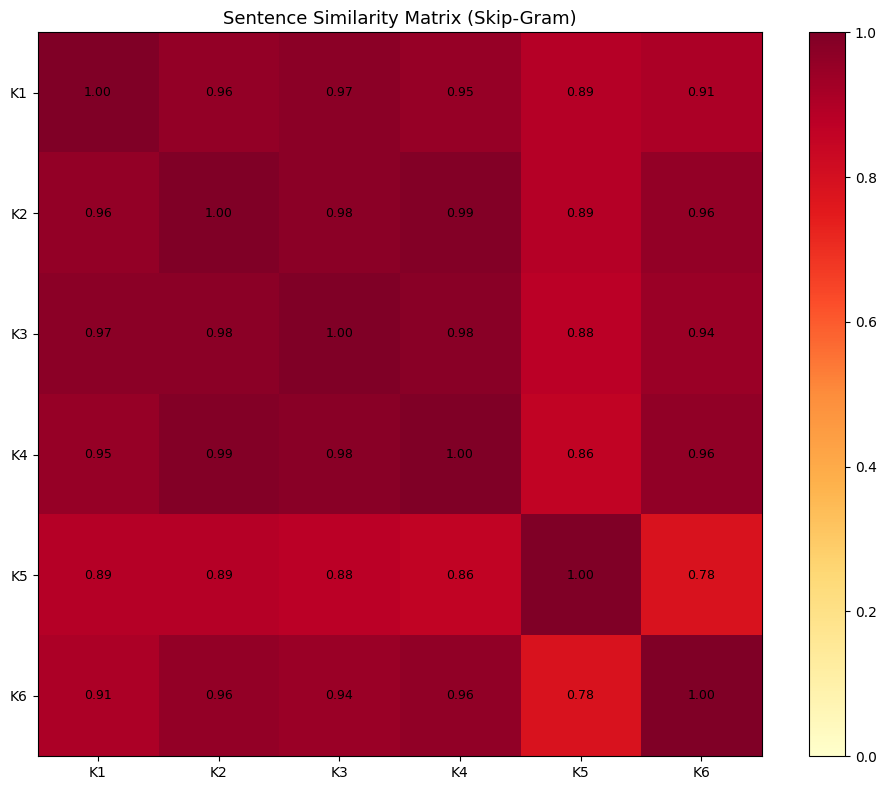


Keterangan:
  K1: Pendidikan di Indonesia terus berkembang
  K2: Sistem pendidikan nasional mengalami kemunduran
  K3: Ekonomi Indonesia tumbuh pesat tahun ini
  K4: Pertumbuhan ekonomi nasional meningkat signifikan
  K5: Bali adalah pulau wisata yang indah
  K6: Presiden Indonesia menetapkan kebijakan baru


In [ ]:
# ============================================================
# USE CASE 2: KEMIRIPAN KALIMAT (Sentence Similarity)
# Aplikasi: Deteksi plagiarisme, FAQ matching, QA system
# ============================================================

def kalimat_ke_vektor(model, kalimat):
    """Rata-rata vektor semua kata dalam kalimat (mean pooling)"""
    kata_list = bersihkan_teks(kalimat).split()
    vektors = [model.wv[k] for k in kata_list if k in model.wv]
    if not vektors:
        return np.zeros(model.vector_size)
    return np.mean(vektors, axis=0)

def hitung_kemiripan_kalimat(model, kalimat1, kalimat2):
    v1 = kalimat_ke_vektor(model, kalimat1).reshape(1, -1)
    v2 = kalimat_ke_vektor(model, kalimat2).reshape(1, -1)
    return cosine_similarity(v1, v2)[0][0]

# Dataset kalimat uji
kalimat_uji = [
    "Pendidikan di Indonesia terus berkembang",
    "Sistem pendidikan nasional mengalami kemunduran",
    "Ekonomi Indonesia tumbuh pesat tahun ini",
    "Pertumbuhan ekonomi nasional meningkat signifikan",
    "Bali adalah pulau wisata yang indah",
    "Presiden Indonesia menetapkan kebijakan baru",
]

print("MATRIKS KEMIRIPAN KALIMAT")
print("=" * 70)
n = len(kalimat_uji)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix[i][j] = hitung_kemiripan_kalimat(model_sg, kalimat_uji[i], kalimat_uji[j])

# Tampilkan heatmap
fig, ax = plt.subplots(figsize=(10, 8))
label_pendek = [f"K{i+1}" for i in range(n)]
im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(label_pendek); ax.set_yticklabels(label_pendek)
plt.colorbar(im, ax=ax)
ax.set_title("Sentence Similarity Matrix (Skip-Gram)", fontsize=13)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Legenda kalimat
print("\nKeterangan:")
for i, k in enumerate(kalimat_uji):
    print(f"  K{i+1}: {k}")

HASIL KLASTERISASI KATA

Klaster 1 (54 kata):
  bahasa, pertanian, masyarakat, politik, nama, selain, hatta, melayu, salah, dua, sosial, pusat, menteri, umum, terdapat...

Klaster 2 (22 kata):
  menjadi, jawa, tersebut, kota, beberapa, besar, pulau, daerah, hingga, pemerintah, abad, kemudian, islam, dunia, mulai...

Klaster 3 (43 kata):
  pendidikan, prabowo, jokowi, teknologi, kata, sebuah, partai, kebudayaan, kebijakan, kesehatan, digunakan, inggris, menyatakan, pasar, bentuk...

Klaster 4 (35 kata):
  jakarta, merupakan, lain, banyak, setelah, memiliki, agama, ekonomi, barat, kerajaan, pertama, timur, bangsa, berbagai, sejak...

Klaster 5 (6 kata):
  indonesia, tahun, negara, belanda, tanggal, wilayah...

Klaster 6 (40 kata):
  presiden, soekarno, orang, terhadap, satu, masa, baru, kepada, portugis, atas, hari, sistem, termasuk, musik, budaya...

Membuat visualisasi t-SNE (mungkin butuh beberapa detik)...


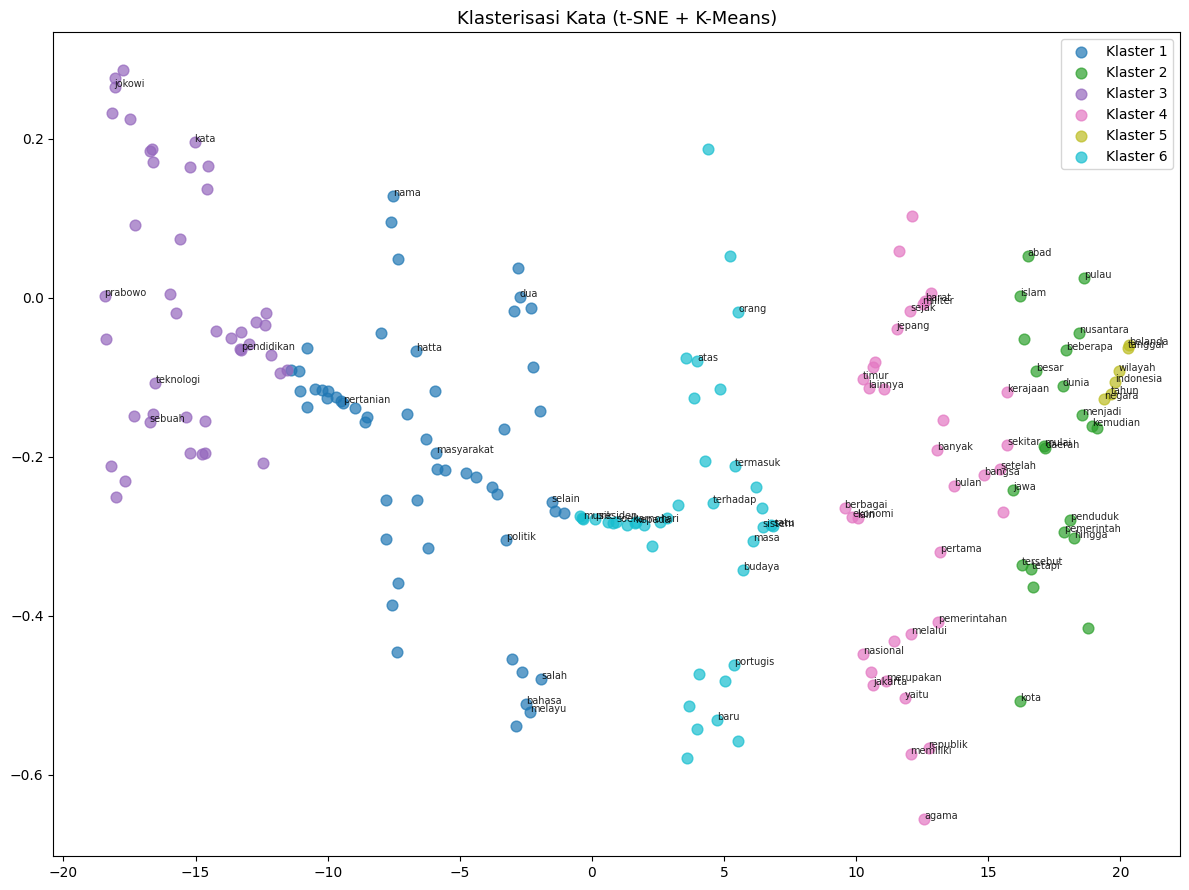

In [ ]:
# ============================================================
# USE CASE 3: KLASTERISASI KATA
# Aplikasi: Topic modeling, pengelompokan dokumen otomatis
# ============================================================

from sklearn.cluster import KMeans

def klasterisasi_kata(model, n_clusters=6, top_words=200):
    # Ambil top N kata berdasarkan frekuensi
    kata_list  = [w for w in list(model.wv.key_to_index.keys())[:top_words]]
    vektor_list = np.array([model.wv[w] for w in kata_list])

    # K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(vektor_list)

    # Kelompokkan hasil
    klaster = {i: [] for i in range(n_clusters)}
    for kata, label in zip(kata_list, labels):
        klaster[label].append(kata)

    return klaster, vektor_list, labels, kata_list

klaster, vektors, labels, kata_list = klasterisasi_kata(model_cbow, n_clusters=6)

print("HASIL KLASTERISASI KATA")
print("=" * 60)
for i, kata_dalam_klaster in klaster.items():
    print(f"\nKlaster {i+1} ({len(kata_dalam_klaster)} kata):")
    print("  " + ", ".join(kata_dalam_klaster[:15]) + "...")

# Visualisasi dengan t-SNE
print("\nMembuat visualisasi t-SNE (mungkin butuh beberapa detik)...")
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vektors)

colors = cm.tab10(np.linspace(0, 1, 6))
plt.figure(figsize=(12, 9))
for i in range(6):
    mask = labels == i
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=[colors[i]], label=f"Klaster {i+1}", alpha=0.7, s=60)

for idx, kata in enumerate(kata_list[:80]):   # Label hanya 80 kata agar tidak penuh
    plt.annotate(kata, coords[idx], fontsize=7, alpha=0.85)

plt.title("Klasterisasi Kata (t-SNE + K-Means)", fontsize=13)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# USE CASE 4: WORD ANALOGY / ARITMATIKA VEKTOR
# "jakarta - jawa + sumatra = ?"
# Aplikasi: Knowledge graph, chatbot, NLP reasoning
# ============================================================

def word_analogy(model, positif, negatif, top_n=10):
    print(f"\n{'='*55}")
    print(f"  {' + '.join(positif)} - {' + '.join(negatif)} = ?")
    print(f"{'='*55}")
    try:
        hasil = model_cbow.wv.most_similar(positive=positif, negative=negatif, topn=top_n)
        for w, score in hasil:
            print(f"  → {w:<20} (similarity: {score:.4f})")
    except KeyError as e:
        print(f"  Kata tidak ditemukan: {e}")

# Contoh analogi geografi & konsep
word_analogy(model_sg, ["presiden", "jakarta"], ["sumatera"])
word_analogy(model_sg, ["presiden", "daerah"],  ["negara"])
word_analogy(model_sg, ["bali", "pariwisata"],  ["jakarta"])
word_analogy(model_sg, ["universitas", "mahasiswa"], ["sekolah"])


  presiden + jakarta - sumatera = ?
  → gubernur             (similarity: 0.9987)
  → selama               (similarity: 0.9987)
  → rakyat               (similarity: 0.9987)
  → menyediakan          (similarity: 0.9986)
  → internasional        (similarity: 0.9986)
  → hingga               (similarity: 0.9986)
  → wangsa               (similarity: 0.9986)
  → kemudian             (similarity: 0.9986)
  → melalui              (similarity: 0.9986)
  → setelah              (similarity: 0.9986)

  presiden + daerah - negara = ?
  → tersebut             (similarity: 0.9992)
  → beberapa             (similarity: 0.9992)
  → provinsi             (similarity: 0.9991)
  → lainnya              (similarity: 0.9991)
  → lokal                (similarity: 0.9991)
  → tingkat              (similarity: 0.9991)
  → tetapi               (similarity: 0.9991)
  → sering               (similarity: 0.9991)
  → wilayah              (similarity: 0.9991)
  → seluruh              (similarity: 0.9991)

  bali +

In [ ]:
# ============================================================
# USE CASE 7: EVALUASI & PERBANDINGAN MODEL
# ============================================================

def bandingkan_model(model_sg, model_cbow, kata_list):
    print(f"\n{'='*65}")
    print(f"{'KATA':<15} {'SKIP-GRAM':<25} {'CBOW':<25}")
    print(f"{'='*65}")

    for kata in kata_list:
        sg_hasil   = model_sg.wv.most_similar(kata, topn=1)[0][0] if kata in model_sg.wv else "N/A"
        cbow_hasil = model_cbow.wv.most_similar(kata, topn=1)[0][0] if kata in model_cbow.wv else "N/A"
        sg_score   = f"{model_sg.wv.most_similar(kata,topn=1)[0][1]:.4f}" if kata in model_sg.wv else "-"
        cbow_score = f"{model_cbow.wv.most_similar(kata,topn=1)[0][1]:.4f}" if kata in model_cbow.wv else "-"
        print(f"{kata:<15} {sg_hasil+' ('+sg_score+')':<25} {cbow_hasil+' ('+cbow_score+')':<25}")

kata_bandingkan = [
    "presiden", "pendidikan", "ekonomi",
    "budaya", "teknologi", "lingkungan"
]
bandingkan_model(model_sg, model_cbow, kata_bandingkan)


# Hitung coverage vocabulary
print(f"\n{'='*45}")
print(f"STATISTIK MODEL")
print(f"{'='*45}")
print(f"Vocab Skip-Gram : {len(model_sg.wv):,} kata")
print(f"Vocab CBOW      : {len(model_cbow.wv):,} kata")
print(f"Embedding dim   : {model_sg.vector_size}")
print(f"Window size     : {model_sg.window}")


KATA            SKIP-GRAM                 CBOW                     
presiden        wakil (0.9764)            pemerintahan (0.9996)    
pendidikan      tentang (0.9827)          melalui (0.9991)         
ekonomi         pertumbuhan (0.9454)      tersebut (0.9998)        
budaya          warisan (0.9612)          dunia (0.9998)           
teknologi       institut (0.9958)         tersebut (0.9976)        
lingkungan      flora (0.9954)            sepanjang (0.9991)       

STATISTIK MODEL
Vocab Skip-Gram : 4,568 kata
Vocab CBOW      : 4,568 kata
Embedding dim   : 100
Window size     : 5
